# Verilere bir göz atalım!

Bu bölümde, Kaggle'dan alınan şu veri setiyle çalışacağız: https://www.kaggle.com/datasets/saurabhbagchi/dish-network-hackathon?select=Train_Dataset.csv

In [3]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np

data = pd.read_csv("Train_Dataset.csv")

/tmp/ipykernel_188197/3858875202.py:5: DtypeWarning: Columns (1,7,8,16,17,18,19,20,35) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("Train_Dataset.csv")


In [4]:
data.head()

,ID,Client_Income,Car_Owned,Bike_Owned,Active_Loan,House_Own,Child_Count,Credit_Amount,Loan_Annuity,Accompany_Client,Client_Income_Type,Client_Education,Client_Marital_Status,Client_Gender,Loan_Contract_Type,Client_Housing_Type,Population_Region_Relative,Age_Days,Employed_Days,Registration_Days,ID_Days,Own_House_Age,Mobile_Tag,Homephone_Tag,Workphone_Working,Client_Occupation,Client_Family_Members,Cleint_City_Rating,Application_Process_Day,Application_Process_Hour,Client_Permanent_Match_Tag,Client_Contact_Work_Tag,Type_Organization,Score_Source_1,Score_Source_2,Score_Source_3,Social_Circle_Default,Phone_Change,Credit_Bureau,Default
0,12142509,6750,0.0,0.0,1.0,0.0,0.0,61190.55,3416.85,Alone,Commercial,Secondary,M,Male,CL,Home,0.028663,13957,1062,6123,383,NaN,1,1,0,Sales,2.0,2.0,6.0,17.0,Yes,Yes,Self-employed,0.568066,0.478787,NaN,0.0186,63.0,NaN,0
1,12138936,20250,1.0,0.0,1.0,NaN,0.0,15282,1826.55,Alone,Service,Graduation,M,Male,CL,Home,0.008575,14162,4129,7833,21,0.0,1,0,1,NaN,2.0,2.0,3.0,10.0,Yes,Yes,Government,0.563360,0.215068,NaN,NaN,NaN,NaN,0
2,12181264,18000,0.0,0.0,1.0,0.0,1.0,59527.35,2788.2,Alone,Service,Graduation dropout,W,Male,CL,Family,0.0228,16790,5102,NaN,331,NaN,1,0,0,Realty agents,2.0,2.0,4.0,NaN,Yes,Yes,Self-employed,NaN,0.552795,0.329655,0.0742,277.0,0.0,0
3,12188929,15750,0.0,0.0,1.0,1.0,0.0,53870.4,2295.45,Alone,Retired,Secondary,M,Male,CL,Home,0.010556,23195,365243,NaN,775,NaN,1,0,0,NaN,2.0,3.0,2.0,15.0,Yes,Yes,XNA,NaN,0.135182,0.631355,NaN,1700.0,3.0,0
4,12133385,33750,1.0,0.0,1.0,0.0,2.0,133988.4,3547.35,Alone,Commercial,Secondary,M,Female,CL,Home,0.020713,11366,2977,5516,4043,6.0,1,0,0,Laborers,4.0,1.0,3.0,NaN,Yes,Yes,Business Entity Type 3,0.508199,0.301182,0.355639,0.2021,674.0,1.0,0


In [7]:
# Kaç kolon var + kolon adları
print("Kolon sayısı:", data.shape[1])
print(*data.columns, sep="\n")



Kolon sayısı: 40
ID
Client_Income
Car_Owned
Bike_Owned
Active_Loan
House_Own
Child_Count
Credit_Amount
Loan_Annuity
Accompany_Client
Client_Income_Type
Client_Education
Client_Marital_Status
Client_Gender
Loan_Contract_Type
Client_Housing_Type
Population_Region_Relative
Age_Days
Employed_Days
Registration_Days
ID_Days
Own_House_Age
Mobile_Tag
Homephone_Tag
Workphone_Working
Client_Occupation
Client_Family_Members
Cleint_City_Rating
Application_Process_Day
Application_Process_Hour
Client_Permanent_Match_Tag
Client_Contact_Work_Tag
Type_Organization
Score_Source_1
Score_Source_2
Score_Source_3
Social_Circle_Default
Phone_Change
Credit_Bureau
Default


In [8]:
# Kolon isimlerini görmek için
data.columns


Index(['ID', 'Client_Income', 'Car_Owned', 'Bike_Owned', 'Active_Loan',
       'House_Own', 'Child_Count', 'Credit_Amount', 'Loan_Annuity',
       'Accompany_Client', 'Client_Income_Type', 'Client_Education',
       'Client_Marital_Status', 'Client_Gender', 'Loan_Contract_Type',
       'Client_Housing_Type', 'Population_Region_Relative', 'Age_Days',
       'Employed_Days', 'Registration_Days', 'ID_Days', 'Own_House_Age',
       'Mobile_Tag', 'Homephone_Tag', 'Workphone_Working', 'Client_Occupation',
       'Client_Family_Members', 'Cleint_City_Rating',
       'Application_Process_Day', 'Application_Process_Hour',
       'Client_Permanent_Match_Tag', 'Client_Contact_Work_Tag',
       'Type_Organization', 'Score_Source_1', 'Score_Source_2',
       'Score_Source_3', 'Social_Circle_Default', 'Phone_Change',
       'Credit_Bureau', 'Default'],
      dtype='object')

In [9]:
X = data.drop(columns=["Default", "ID"])
y = data.Default

In [10]:
y.value_counts(normalize = True)

Default
0    0.919208
1    0.080792
Name: proportion, dtype: float64

value_counts() sınıfların kaç tane olduğunu sayar.

normalize=True bunu oran (yüzde) olarak verir.

Çıktın:

0 0.919208 → sınıf 0 yaklaşık %91.92

1 0.080792 → sınıf 1 yaklaşık %8.08

Bu ne anlama geliyor?

Bu veri dengesiz (imbalanced).
Yani “Default=1” (muhtemelen temerrüt) azınlık sınıf.

Risk: Model “hep 0” dese bile ~%92 accuracy alır. Bu yüzden accuracy tek başına yanıltır.
Bu durumda genelde precision/recall, F1, ROC-AUC, PR-AUC gibi metriklere bakılır ve stratified split tercih edilir.

In [11]:
data.info()
data.isna().mean().sort_values(ascending=False).head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121856 entries, 0 to 121855
Data columns (total 40 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   ID                          121856 non-null  int64  
 1   Client_Income               118249 non-null  object 
 2   Car_Owned                   118275 non-null  float64
 3   Bike_Owned                  118232 non-null  float64
 4   Active_Loan                 118221 non-null  float64
 5   House_Own                   118195 non-null  float64
 6   Child_Count                 118218 non-null  float64
 7   Credit_Amount               118224 non-null  object 
 8   Loan_Annuity                117044 non-null  object 
 9   Accompany_Client            120110 non-null  object 
 10  Client_Income_Type          118155 non-null  object 
 11  Client_Education            118211 non-null  object 
 12  Client_Marital_Status       118383 non-null  object 
 13  Client_Gender 

Own_House_Age                 0.657292
Score_Source_1                0.564888
Social_Circle_Default         0.508206
Client_Occupation             0.340032
Score_Source_3                0.220925
Credit_Bureau                 0.152147
ID_Days                       0.048976
Score_Source_2                0.046662
Population_Region_Relative    0.039859
Loan_Annuity                  0.039489
dtype: float64

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Ne oluyor?

Verinin %80’i train, %20’si test

random_state=42 → her çalıştırmada aynı bölünme

stratify=y → sınıf oranları korunuyor

Neden stratify=y çok önemli?

Bir önceki adımda gördük:

Default=1 ≈ %8

Default=0 ≈ %92

Eğer stratify yapmasaydın:

Test setinde 1 çok az kalabilir

Recall / precision tamamen bozulur

Yani dengesiz veri + stratify yok = yanlış model değerlendirmesi.

In [13]:
X_train.dtypes

Client_Income                  object
Car_Owned                     float64
Bike_Owned                    float64
Active_Loan                   float64
House_Own                     float64
Child_Count                   float64
Credit_Amount                  object
Loan_Annuity                   object
Accompany_Client               object
Client_Income_Type             object
Client_Education               object
Client_Marital_Status          object
Client_Gender                  object
Loan_Contract_Type             object
Client_Housing_Type            object
Population_Region_Relative     object
Age_Days                       object
Employed_Days                  object
Registration_Days              object
ID_Days                        object
Own_House_Age                 float64
Mobile_Tag                      int64
Homephone_Tag                   int64
Workphone_Working               int64
Client_Occupation              object
Client_Family_Members         float64
Cleint_City_

In [14]:
# Maalesef burada bir hata alıyoruz!
X_train["Client_Income"].astype(float)

ValueError: could not convert string to float: '$'

In [15]:
col_to_fix = ["Score_Source_3",
              "Client_Income",
              "Credit_Amount",
              "Loan_Annuity",
              "Age_Days",
              "Employed_Days",
              "Registration_Days",
              "ID_Days",
              "Population_Region_Relative"
             ]

# Pipeline’ı oluşturma ve veri tipini düzeltme!

In [16]:
import string

print(string.punctuation)
print(string.ascii_letters)

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~
abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ


In [17]:
string.punctuation.replace(".", "") + string.ascii_letters

'!"#$%&\'()*+,-/:;<=>?@[\\]^_`{|}~abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ'

In [18]:
def clean_df(X):

    def clean_value(value):
        unwanted_char = string.punctuation.replace(".", "") + string.ascii_letters
        for tag in unwanted_char:
            value = value.replace(tag, "")
        value = np.nan if not value else value
        return float(value)

    X = pd.DataFrame(X)
    X = X.astype(str).map(clean_value)
    return X


In [19]:
from sklearn.pipeline import Pipeline, FunctionTransformer
from sklearn.compose import ColumnTransformer, make_column_selector

In [20]:
cleaner = FunctionTransformer(clean_df)

type_cleaner = ColumnTransformer(
    [("type_cleaner", cleaner, col_to_fix)],
    remainder="passthrough"
    ).set_output(transform = "pandas")

In [21]:
type_cleaner.fit_transform(X_train)

,type_cleaner__Score_Source_3,type_cleaner__Client_Income,type_cleaner__Credit_Amount,type_cleaner__Loan_Annuity,type_cleaner__Age_Days,type_cleaner__Employed_Days,type_cleaner__Registration_Days,type_cleaner__ID_Days,type_cleaner__Population_Region_Relative,remainder__Car_Owned,remainder__Bike_Owned,remainder__Active_Loan,remainder__House_Own,remainder__Child_Count,remainder__Accompany_Client,remainder__Client_Income_Type,remainder__Client_Education,remainder__Client_Marital_Status,remainder__Client_Gender,remainder__Loan_Contract_Type,remainder__Client_Housing_Type,remainder__Own_House_Age,remainder__Mobile_Tag,remainder__Homephone_Tag,remainder__Workphone_Working,remainder__Client_Occupation,remainder__Client_Family_Members,remainder__Cleint_City_Rating,remainder__Application_Process_Day,remainder__Application_Process_Hour,remainder__Client_Permanent_Match_Tag,remainder__Client_Contact_Work_Tag,remainder__Type_Organization,remainder__Score_Source_1,remainder__Score_Source_2,remainder__Social_Circle_Default,remainder__Phone_Change,remainder__Credit_Bureau
4664,0.675413,22500.0,94050.00,3729.60,NaN,2686.0,2928.0,4258.0,0.026392,1.0,0.0,1.0,1.0,0.0,Relative,Service,Secondary,S,Male,NaN,Home,3.0,1,1,1,Sales,1.0,2.0,5.0,13.0,Yes,Yes,Business Entity Type 3,0.366184,0.515763,0.1464,528.0,0.0
99005,0.403142,13500.0,67500.00,1780.65,9921.0,551.0,776.0,1346.0,0.026392,0.0,0.0,0.0,0.0,0.0,Alone,Service,Graduation,M,Male,CL,Home,NaN,1,1,1,Core,2.0,2.0,2.0,14.0,Yes,Yes,Bank,NaN,0.591244,0.2619,338.0,2.0
48107,0.157595,10350.0,13940.55,769.05,10475.0,3637.0,10241.0,3158.0,0.020246,0.0,1.0,1.0,1.0,2.0,Alone,NaN,Secondary,M,Male,CL,Family,NaN,1,0,0,Sales,4.0,3.0,4.0,7.0,Yes,Yes,Self-employed,0.454473,0.319012,NaN,1040.0,7.0
97976,NaN,14850.0,72000.00,3050.55,22194.0,365243.0,8110.0,5256.0,0.072508,0.0,0.0,0.0,1.0,0.0,Alone,Retired,Secondary,S,Male,CL,Home,NaN,1,0,1,NaN,1.0,1.0,2.0,NaN,Yes,Yes,XNA,NaN,0.631997,0.2598,334.0,0.0
78034,0.560284,11250.0,63450.00,NaN,12924.0,285.0,7029.0,4648.0,0.014520,0.0,0.0,0.0,0.0,0.0,Alone,Service,Junior secondary,D,Female,CL,Family,NaN,1,0,0,Laborers,1.0,2.0,4.0,6.0,Yes,No,Business Entity Type 2,0.172293,0.229854,NaN,1588.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93313,NaN,14400.0,63448.20,2471.40,11396.0,1584.0,4586.0,NaN,NaN,1.0,1.0,0.0,1.0,1.0,Relative,Commercial,Secondary,M,Female,CL,Home,22.0,1,0,1,Laborers,3.0,2.0,2.0,14.0,Yes,Yes,Industry: type 4,NaN,0.117043,NaN,323.0,NaN
24114,NaN,11250.0,23985.00,2336.40,23171.0,365243.0,5390.0,4552.0,0.009334,0.0,1.0,0.0,1.0,0.0,Alone,Retired,Secondary,NaN,NaN,CL,Home,NaN,1,0,0,NaN,2.0,2.0,5.0,13.0,Yes,Yes,XNA,NaN,0.540016,0.0938,764.0,1.0
14180,NaN,18000.0,58476.60,2331.90,20951.0,3479.0,8343.0,4050.0,0.006233,0.0,1.0,1.0,1.0,0.0,Alone,NaN,Secondary,M,Female,NaN,Home,NaN,1,0,0,Laborers,2.0,2.0,3.0,15.0,Yes,Yes,Business Entity Type 3,NaN,0.443989,NaN,12.0,NaN
105783,0.812823,4500.0,22500.00,1613.25,16056.0,1233.0,3691.0,4327.0,0.010556,0.0,1.0,1.0,1.0,0.0,Alone,Service,Secondary,M,Male,CL,Home,NaN,1,1,1,Laborers,2.0,3.0,4.0,15.0,Yes,Yes,Business Entity Type 3,0.675231,0.573423,0.1732,2750.0,0.0


In [22]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [23]:
num_preproc = Pipeline([
    ("num_imputer", SimpleImputer(strategy="constant", fill_value=0.)),
    ("scaler", StandardScaler())
])

In [24]:
cat_preproc = Pipeline([
    ("cat_imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

In [25]:
preproc = ColumnTransformer([
    ("num_tr", num_preproc, make_column_selector(dtype_include=["float64", "int64"])),
    ("cat_tr", cat_preproc, make_column_selector(dtype_include=["object"]))
])

In [26]:
clean_preproc = Pipeline([
    ("cleaner", type_cleaner),
    ("preprocessing", preproc)])

In [27]:
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ("clean_preproc", clean_preproc),
    ("classifier", LogisticRegression(max_iter=1000))
])

pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('clean_preproc', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('cleaner', ...), ('preprocessing', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 

In [28]:
from sklearn.model_selection import cross_val_score

In [29]:
cross_val_score(pipe, X_train, y_train).mean()

np.float64(0.919166221589092)

# Bir dakika, işleri doğru mu yapıyoruz?

## Cross-validation yaparken dikkatli olmamız gerekiyor!


Dengesiz dataset’lerle 🌓 çalışırken, **Stratified K-Fold Cross-Validation** ile kendimizi donatalım! 🛡️🔄

Peki neden? 🤔

1. **Standart K-Fold** 🔄:  
   Bazı fold’larda azınlık sınıfını tamamen dışarıda bırakabilir 😨!  
   Bu da model değerlendirmesinin daha az güvenilir olmasına yol açar. 😢

2. **Stratified K-Fold** 🔀:  
   Her fold’un ⚙️ çoğunluk ve azınlık sınıflarından **uygun oranlarda** içermesini sağlar. 🎉

3. **Güvenilir Değerlendirme** 🎯:  
   Gerçek dünya performansını 🌍 daha iyi temsil eder.  
   Her iki sınıfı da dengede tutar! 🤹‍♂️

4. **Daha İyi Model Ayarı** 🚀:  
   Modelinizin azınlık sınıfını nasıl ele aldığını daha net görerek,  
   parametreleri daha bilinçli şekilde optimize etmenizi sağlar! 🕵️‍♀️

In [30]:
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits=5)

cross_val_score(pipe, X_train, y_train, cv=cv).mean()

np.float64(0.919166221589092)

Bir dakika… Bu, öncekiyle **aynı sonuç** değil mi?

Gel, birlikte scikit-learn dokümantasyonunda `cross_validate()` fonksiyonuna bakalım ve özellikle `cv` parametresini inceleyelim.

<details>
  <summary><strong>Açıklama</strong></summary>

  Görünen o ki, scikit-learn varsayılan olarak **`StratifiedKFold`** kullanıyor.  
  Yani `cv=None` ya da `cv=k` (burada `k` istediğimiz fold sayısı) belirttiğimizde, classifier kullanılıyorsa stratification **otomatik olarak** uygulanıyor.

</details>

## Accuracy ile ilgili sorun nedir?

Dengesiz dataset’lerde 🌓, **precision-recall AUC** 📈 kraldır! 🤴

Neden mi? 🤔

- **Accuracy** 🎯, dengesiz dataset’lerde yanıltıcı olabilir. 😱

- **Yüksek recall**? Harika, ama **false positive**’lere dikkat! 🚨

- **Precision-Recall AUC**, farklı threshold’lar boyunca hem precision hem recall’u birlikte değerlendirir. 🌟  
  Eğri altındaki alan ne kadar büyükse = model o kadar iyi! 💪

- Tek bir sayıyla özet almak için sklearn’de **`average_precision_score`** 🛠️ kullanın. 🧮

Hadi buna bir göz atalım: https://scikit-learn.org/stable/auto_examples/model_selection/plot_precision_recall.html#sphx-glr-auto-examples-model-selection-plot-precision-recall-py

In [31]:
cv = StratifiedKFold(n_splits=5)
cross_val_score(pipe, X_train, y_train, cv=cv, scoring="average_precision").mean()

np.float64(0.17780604538717706)

In [32]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('clean_preproc', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('cleaner', ...), ('preprocessing', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 

In [33]:
X_test.head()

,Client_Income,Car_Owned,Bike_Owned,Active_Loan,House_Own,Child_Count,Credit_Amount,Loan_Annuity,Accompany_Client,Client_Income_Type,Client_Education,Client_Marital_Status,Client_Gender,Loan_Contract_Type,Client_Housing_Type,Population_Region_Relative,Age_Days,Employed_Days,Registration_Days,ID_Days,Own_House_Age,Mobile_Tag,Homephone_Tag,Workphone_Working,Client_Occupation,Client_Family_Members,Cleint_City_Rating,Application_Process_Day,Application_Process_Hour,Client_Permanent_Match_Tag,Client_Contact_Work_Tag,Type_Organization,Score_Source_1,Score_Source_2,Score_Source_3,Social_Circle_Default,Phone_Change,Credit_Bureau
72090,11250,0.0,1.0,1.0,0.0,2.0,45000.0,2188.8,Alone,Govt Job,Secondary,NaN,Male,CL,Home,0.010147,10150,1162,2774,2761,NaN,1,1,1,Core,4.0,2.0,5.0,9.0,No,Yes,Kindergarten,0.116349,0.723169,0.28813,NaN,998.0,4.0
2322,7650,0.0,0.0,1.0,1.0,0.0,64008,2997,Alone,Service,Secondary,M,Male,CL,Home,0.020246,13127,144,1824,1168,NaN,1,0,0,Laborers,2.0,3.0,4.0,8.0,Yes,Yes,Housing,NaN,0.239566,0.519097,NaN,1988.0,2.0
29120,9000,1.0,1.0,0.0,1.0,0.0,135000.0,4862.25,Alone,Service,Graduation,M,Male,CL,Home,0.026392,15484,4974,7194,4233,7.0,1,0,0,High skill tech,2.0,2.0,3.0,13.0,Yes,No,Transport: type 4,0.803901,0.542177,0.621226338,0.4959,0.0,0.0
63005,12150.0,0.0,1.0,0.0,1.0,0.0,83560.5,2456.1,Alone,Retired,Secondary,W,Male,CL,Home,0.015221,20668,365243,6142,4173,NaN,1,0,0,NaN,1.0,NaN,5.0,13.0,Yes,Yes,XNA,NaN,NaN,0.385915,NaN,534.0,2.0
6137,NaN,0.0,0.0,1.0,1.0,0.0,45000,2732.4,Relative,Retired,Secondary,S,Male,CL,Home,0.010966,22966,365243,9204,4835,NaN,1,0,0,NaN,1.0,2.0,3.0,11.0,Yes,Yes,XNA,NaN,0.502642,0.546023,0.1031,2301.0,2.0


In [35]:
from sklearn.metrics import PrecisionRecallDisplay, precision_recall_curve

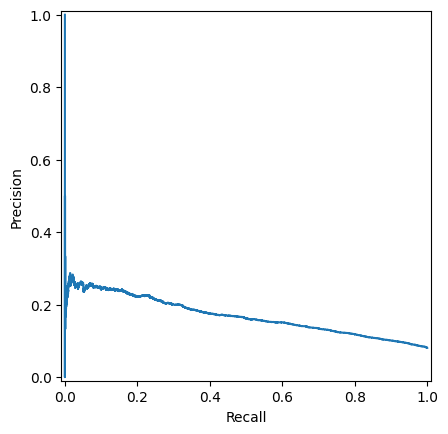

In [36]:
y_pred_prob = pipe.predict_proba(X_test)[:,1]

precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
disp = PrecisionRecallDisplay(precision=precision, recall=recall)
disp.plot()

## Daha karmaşık bir model deneyelim

In [37]:
from sklearn.ensemble import RandomForestClassifier

In [38]:
pipe = Pipeline([
    ("cleaner", type_cleaner),
    ("preprocessing", preproc),
    ("classifier", RandomForestClassifier())
])

In [39]:
cv = StratifiedKFold(n_splits=5)
cross_val_score(pipe, X_train, y_train, cv=cv, scoring="average_precision").mean()

np.float64(0.35407710794509556)

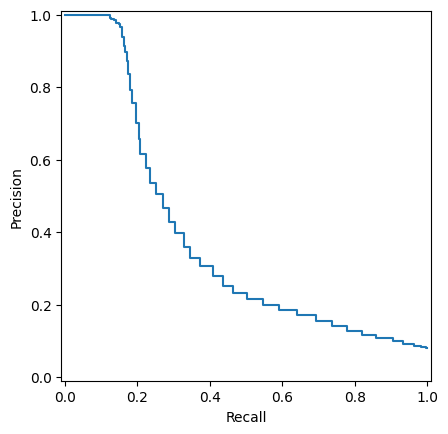

In [40]:
pipe.fit(X_train, y_train)
y_pred_prob = pipe.predict_proba(X_test)[:,1]

precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
disp = PrecisionRecallDisplay(precision=precision, recall=recall)
disp.plot()

In [41]:
y_pred_prob

array([0.09, 0.1 , 0.05, ..., 0.05, 0.03, 0.13], shape=(24372,))

## Sınıf dengesizliğini hesaba katalım

In [42]:
pipe = Pipeline([
    ("cleaner", type_cleaner),
    ("preprocessing", preproc),
    ("classifier", RandomForestClassifier(class_weight="balanced"))
])

In [43]:
cv = StratifiedKFold(n_splits=5)
cross_val_score(pipe, X_train, y_train, cv=cv, scoring="average_precision").mean()

np.float64(0.3607684129058291)

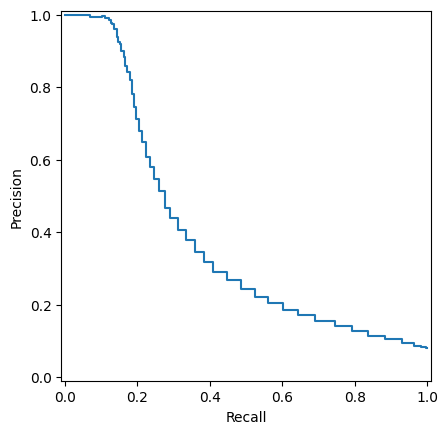

In [44]:
pipe.fit(X_train, y_train)
y_pred_prob = pipe.predict_proba(X_test)[:,1]


precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
disp = PrecisionRecallDisplay(precision=precision, recall=recall)
disp.plot()

# Model Kalibrasyonu

Şunu bir hayal et: Olasılıklar üreten harika bir model 🌟 geliştirdin. Sen mutlusun, modelin mutlu, ama DUR! Bu olasılıklar gerçekten güvenilir mi? 🤔

🎺 Sahneye çıkıyor: Model Calibration! 🎺

İşte neden bunun, model dondurmanın 🍨 üzerindeki vişne 🍒 gibi olduğunu açıklayan sebepler:

1. Güvenilir Olasılıklar 📊: Modelin yağmur olasılığının %80 olduğunu söylüyorsa ☔, gerçekten de yaklaşık zamanın %80’inde yağmur yağmalıdır! Calibration, çıktı olarak üretilen olasılıkların olayların gerçek gerçekleşme ihtimalini yansıtmasını sağlar.

2. Bilinçli Kararlar 💡: Calibrated olasılıklar sayesinde daha akıllı kararlar verebilirsin! Bu, macerana çıkarken ne kadar dragon repellent 🐲 taşıman gerektiğini tam olarak bilmeye benzer.

3. Model Karşılaştırması 🤺: İki model girer, bir model çıkar! Modelleri karşılaştırırken, iyi calibrated edilmiş olasılıklar, tahminlerin Excalibur 🗡️’unu kullanabilecek gerçek kahramanı 🦸 seçmene yardımcı olur!

4. Daha İyi Risk Yönetimi 💼: Finans, sağlık veya riskin yüksek olduğu herhangi bir alanda karar vermek, iksirlerle jonglörlük yapmak 🧪 gibidir. Calibrated olasılıklar, iksir karışımını tam kararında tutar!

5. Özel Thresholds 🚥: Her savaş aynı şekilde verilmez! Bazen stratejini değiştirmen gerekir. Calibrated olasılıklar, hedefinin gerektirdiği şekilde precision veya recall için optimize edebilmen adına özel thresholds belirlemene olanak tanır.

Şuna bir göz atalım: [https://scikit-learn.org/stable/modules/calibration.html#calibration](https://scikit-learn.org/stable/modules/calibration.html#calibration)


In [45]:
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay, calibration_curve

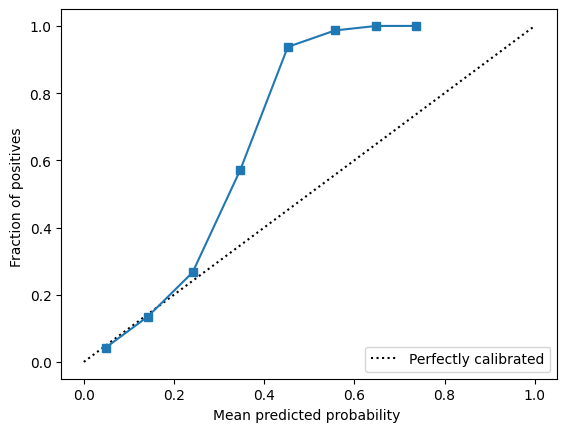

In [46]:
prob_true, prob_pred = calibration_curve(y_test, y_pred_prob, n_bins=10)

disp = CalibrationDisplay(prob_true, prob_pred, y_pred_prob)
disp.plot()

In [47]:
calibrated_clf = CalibratedClassifierCV(pipe, cv=cv)
calibrated_clf.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",Pipeline(step...'balanced'))])
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, 

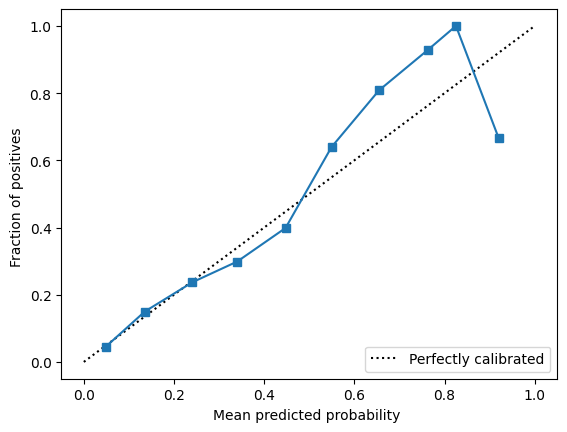

In [48]:
y_pred_prob = calibrated_clf.predict_proba(X_test)[:,1]

prob_true, prob_pred = calibration_curve(y_test, y_pred_prob, n_bins=10)

disp = CalibrationDisplay(prob_true, prob_pred, y_pred_prob)
disp.plot()

In [49]:
# Not: Bu işlemin tamamlanması oldukça uzun sürebilir!
cv = StratifiedKFold(n_splits=5)
cross_val_score(calibrated_clf, X_train, y_train, cv=cv, scoring="average_precision").mean()

np.float64(0.37698605455901435)

# Sonraki Adımlar

Calibrated bir modelimiz var, ancak işimiz henüz bitmedi! Eğer performanslardan memnun değilsek şunları uygulayabiliriz:

-Parameter Tuning (Grid Search)

-Daha da gelişmiş modeller denemek

-Oversampling veya Undersampling uygulamak

Son seçeneğe hızlıca bir göz atalım; bunun için Imbalanced-Learn library kullanacağız.

In [51]:
!pip install imbalanced-learn

  Using cached scikit_learn-1.6.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (18 kB)
Using cached scikit_learn-1.6.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (13.1 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.8.0
    Uninstalling scikit-learn-1.8.0:
      Successfully uninstalled scikit-learn-1.8.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mlxtend 0.24.0 requires scikit-learn>=1.8.0, but you have scikit-learn 1.6.1 which is incompatible.


In [52]:
X_train_preproc = clean_preproc.fit_transform(X_train)

In [53]:
print(X_train_preproc.shape)
print(y_train.value_counts())

(97484, 151)
Default
0    89608
1     7876
Name: count, dtype: int64


In [55]:
import sklearn
import imblearn
print("sklearn:", sklearn.__version__)
print("imblearn:", imblearn.__version__)


ImportError: cannot import name '_is_pandas_df' from 'sklearn.utils.validation' (/home/tumay/.pyenv/versions/workintech/lib/python3.12/site-packages/sklearn/utils/validation.py)

In [56]:
pip install -U scikit-learn imbalanced-learn


  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (8.9 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Attempting uninstall: sklearn-compat━━━━━━━━━━ 0/3 [scikit-learn]
    Found existing installation: sklearn-compat 0.1.3m0/3 [scikit-learn]
    Uninstalling sklearn-compat-0.1.3:━━━━━━ 0/3 [scikit-learn]
      Successfully uninstalled sklearn-compat-0.1.332m0/3 [scikit-learn]
  Attempting uninstall: imbalanced-learn━━━━ 0/3 [scikit-learn]
    Found existing installation: imbalanced-learn 0.13.03 [scikit-learn]
    Uninstalling imbalanced-learn-0.13.0:━━━ 0/3 [scikit-learn]
      Successfully uninstalled imbalanced-learn-0.13.00/3 [scikit-learn]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [imbalanced-

## Aşırı örnekleme - SMOTE

SMOTE, azınlık sınıfını güçlendirmek için yeni, sentetik örnekler oluşturan bir sanatçı gibidir. Bunu, mevcut azınlık örnekleri arasında interpolation yaparak gerçekleştirir. Amaç, azınlık sınıfını daha büyük hale getirmek ve böylece model için daha anlamlı olmasını sağlamaktır. Ancak dikkatli olun! SMOTE, bazen orijinal örneklerden çok uzak sentetik örnekler üreterek gürültü oluşturabilir.

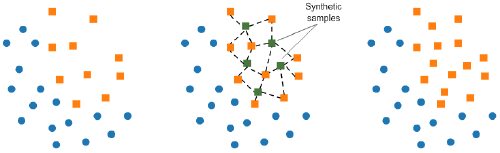

In [57]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_preproc, y_train)

print(X_train_res.shape)
print(y_train_res.shape)
y_train_res.value_counts()

Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7b502f0449a0>
Traceback (most recent call last):
  File "/home/tumay/.pyenv/versions/workintech/lib/python3.12/site-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/home/tumay/.pyenv/versions/workintech/lib/python3.12/site-packages/threadpoolctl.py", line 1175, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/home/tumay/.pyenv/versions/workintech/lib/python3.12/site-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/tumay/.pyenv/versions/3.12.9/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                  

(179216, 151)
(179216,)


Default
0    89608
1    89608
Name: count, dtype: int64

## Alt örnekleme - Rastgele Alt Örnekleyici

RUS’u, veri setini dengelemek için çoğunluk sınıfından bazı örnekleri rastgele atan bir atık bertaraf ünitesi gibi hayal et. Bunu yaparak modelin azınlık sınıfına daha fazla odaklanmasını sağlar. Ancak veri attığı için, faydalı bilgileri de gözden çıkarabilir. Bu yüzden RUS’u dikkatli kullan!

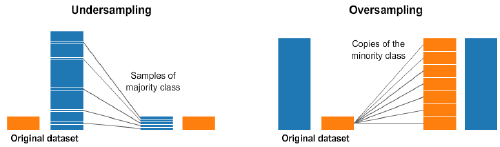

In [58]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train_preproc, y_train)

print(X_train_res.shape)
print(y_train_res.shape)
y_train_res.value_counts()


(15752, 151)
(15752,)


Default
0    7876
1    7876
Name: count, dtype: int64

## Alt örnekleme - Tomek Link

Tomek Links, birbirine yakın çoğunluk ve azınlık sınıfı örnek çiftlerini (bir ‘link’ oluşturarak) kendine çeken bir mıknatıs gibi davranır. Eğer bir çoğunluk sınıfı örneği bir Tomek Link oluşturursa, bu örnek kaldırılır ve sınıflar arasındaki borderline’ın temizlenmesine yardımcı olunur. Bu ‘borderline’ çoğunluk örneklerinin kaldırılması, modelin çoğunluk sınıfına karşı daha az biased olmasını sağlayabilir. Ancak, dengesizlik çok şiddetliyse bu yöntem yeterli olmayabilir.

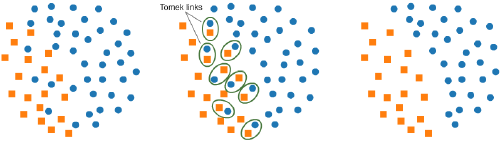

In [59]:
from imblearn.under_sampling import TomekLinks

tl = TomekLinks()
X_train_res, y_train_res = tl.fit_resample(X_train_preproc, y_train)

print(X_train_res.shape)
print(y_train_res.shape)
y_train_res.value_counts()


(95977, 151)
(95977,)


Default
0    88101
1     7876
Name: count, dtype: int64